In [1]:
# =====================
# 子模块1: 数据读取与统一
# =====================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT_DIR = Path(
    "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train"
)
AF3_PATH = ROOT_DIR / "data/source-nopackinput/af3_rosetta.csv"
ROSETTA_PATH = ROOT_DIR / "data/source-nopackinput/rosetta.csv"
OUTPUT_DIR = ROOT_DIR / "data/train_result/nopackinput"

FEATURE_COLUMNS = [
    "dG_separated/dSASAx100",
    "energy_per_intres",
    "dSASA_int_per_res",
    "Hbond_per_res",
    "sc_value",
]
SOURCE_COLUMN = "source"
TARGET_COLUMN = "target"
LABEL_COLUMN = "label"

N_SPLITS = 5
N_REPEATS = 50
BASE_SEED = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def load_source_table(path: Path, source_name: str) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    required_columns = [TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {path.name}: {missing_columns}")

    df[SOURCE_COLUMN] = source_name

    for column in FEATURE_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df[LABEL_COLUMN] = pd.to_numeric(df[LABEL_COLUMN], errors="coerce")
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str)

    selected_columns = [SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS
    return df.loc[:, selected_columns].copy()


af3_df = load_source_table(AF3_PATH, "AF3")
rosetta_df = load_source_table(ROSETTA_PATH, "Rosetta")
all_df = pd.concat([af3_df, rosetta_df], ignore_index=True)

all_df = all_df.dropna(subset=[TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS).copy()
all_df[LABEL_COLUMN] = all_df[LABEL_COLUMN].astype(int)

exact_duplicate_mask = all_df.duplicated(
    subset=[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS
)
exact_duplicate_count = int(exact_duplicate_mask.sum())
if exact_duplicate_count > 0:
    print(f"Found and removed {exact_duplicate_count} exact duplicate rows.")
    all_df = all_df.loc[~exact_duplicate_mask].copy()

all_df = all_df.reset_index(drop=True)
model_df = all_df[[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS].copy()

print(f"AF3 rows: {len(af3_df)}")
print(f"Rosetta rows: {len(rosetta_df)}")
print(f"Combined rows: {len(model_df)}")
print("\nRows by source:")
print(model_df.groupby(SOURCE_COLUMN).size())
print("\nLabel counts by source:")
print(model_df.groupby([SOURCE_COLUMN, LABEL_COLUMN]).size().unstack(fill_value=0))
print("\nUnique targets by source:")
print(model_df.groupby(SOURCE_COLUMN)[TARGET_COLUMN].nunique())
print("\nCombined target count:")
print(model_df[TARGET_COLUMN].nunique())

ValueError: Missing columns in rosetta.csv: ['target']

In [ ]:
# =====================
# 子模块2: 训练、分组与评估工具
# =====================


def build_model(random_state: int) -> Pipeline:
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=1000,
                    solver="lbfgs",
                    penalty="l2",
                    random_state=random_state,
                ),
            ),
        ]
    )


def compute_sample_weights(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    if y.size == 0:
        raise ValueError("Cannot compute sample weights for an empty label array.")

    class_counts = pd.Series(y).value_counts().to_dict()
    n_samples = float(len(y))
    n_classes = float(len(class_counts))
    return np.asarray(
        [n_samples / (n_classes * class_counts[int(label)]) for label in y],
        dtype=float,
    )


def extract_raw_parameters(model: Pipeline) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray, float, np.ndarray, float]:
    scaler = model.named_steps["scaler"]
    clf = model.named_steps["clf"]

    standardized_coef = np.asarray(clf.coef_[0], dtype=float)
    standardized_intercept = float(clf.intercept_[0])

    scale = np.asarray(scaler.scale_, dtype=float)
    mean = np.asarray(scaler.mean_, dtype=float)

    raw_coef = standardized_coef / scale
    raw_intercept = standardized_intercept - float(np.sum((standardized_coef * mean) / scale))

    raw_table = pd.DataFrame(
        {
            "term": ["bias"] + FEATURE_COLUMNS,
            "coefficient": [raw_intercept] + list(raw_coef),
            "space": ["raw"] * (len(FEATURE_COLUMNS) + 1),
        }
    )
    standardized_table = pd.DataFrame(
        {
            "term": ["bias"] + FEATURE_COLUMNS,
            "coefficient": [standardized_intercept] + list(standardized_coef),
            "space": ["standardized"] * (len(FEATURE_COLUMNS) + 1),
        }
    )

    return (
        raw_table,
        standardized_table,
        raw_coef,
        raw_intercept,
        standardized_coef,
        standardized_intercept,
    )


def summarize_fold_distribution(df: pd.DataFrame, fold_assignment: np.ndarray) -> pd.DataFrame:
    fold_rows = []
    for fold_idx in range(N_SPLITS):
        fold_df = df.loc[fold_assignment == fold_idx]
        pos_count = int((fold_df[LABEL_COLUMN] == 1).sum())
        neg_count = int((fold_df[LABEL_COLUMN] == 0).sum())
        af3_count = int((fold_df[SOURCE_COLUMN] == "AF3").sum())
        rosetta_count = int((fold_df[SOURCE_COLUMN] == "Rosetta").sum())

        fold_rows.append(
            {
                "fold": fold_idx,
                "n_samples": int(len(fold_df)),
                "n_targets": int(fold_df[TARGET_COLUMN].nunique()),
                "n_pos": pos_count,
                "n_neg": neg_count,
                "n_af3": af3_count,
                "n_rosetta": rosetta_count,
                "label_gap": abs(pos_count - neg_count),
                "source_gap": abs(af3_count - rosetta_count),
                "has_both_labels": bool(pos_count > 0 and neg_count > 0),
                "has_both_sources": bool(af3_count > 0 and rosetta_count > 0),
            }
        )

    return pd.DataFrame(fold_rows)


def fold_quality_score(fold_summary: pd.DataFrame, total_rows: int) -> float:
    size_target = float(total_rows) / float(N_SPLITS)
    size_gap = float((fold_summary["n_samples"] - size_target).abs().sum())
    label_gap = float(fold_summary["label_gap"].sum())
    source_gap = float(fold_summary["source_gap"].sum())
    pure_label_penalty = 1_000_000.0 * float((~fold_summary["has_both_labels"]).sum())
    pure_source_penalty = 1_000_000.0 * float((~fold_summary["has_both_sources"]).sum())

    return size_gap + label_gap + source_gap + pure_label_penalty + pure_source_penalty


def build_source_balanced_split(
    df: pd.DataFrame,
    seed: int,
    n_splits: int = N_SPLITS,
    max_attempts: int = 50,
) -> tuple[np.ndarray, pd.DataFrame, int, int, float]:
    if n_splits < 2:
        raise ValueError("n_splits must be at least 2.")

    strata = (
        df[SOURCE_COLUMN].astype(str)
        + "__"
        + df[LABEL_COLUMN].astype(int).astype(str)
    )
    groups = df[TARGET_COLUMN].astype(str).to_numpy()

    best_assignment = None
    best_summary = None
    best_score = float("inf")
    best_attempt_seed = seed
    best_attempt_count = 1

    for attempt_idx in range(max_attempts):
        attempt_seed = seed + attempt_idx * 7919 
        splitter = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=attempt_seed,
        )

        fold_assignment = np.full(len(df), -1, dtype=int)
        for fold_idx, (_, test_idx) in enumerate(
            splitter.split(np.zeros(len(df)), strata, groups)
        ):
            fold_assignment[test_idx] = fold_idx

        if (fold_assignment < 0).any():
            raise RuntimeError("Fold assignment is incomplete.")

        fold_summary = summarize_fold_distribution(df, fold_assignment)
        score = fold_quality_score(fold_summary, len(df))

        if score < best_score:
            best_score = score
            best_assignment = fold_assignment.copy()
            best_summary = fold_summary.copy()
            best_attempt_seed = attempt_seed
            best_attempt_count = attempt_idx + 1

        if fold_summary["has_both_labels"].all() and fold_summary["has_both_sources"].all():
            return fold_assignment, fold_summary, attempt_idx + 1, attempt_seed, score

    if best_assignment is None or best_summary is None:
        raise RuntimeError("Failed to construct a valid group-stratified split.")

    return best_assignment, best_summary, best_attempt_count, best_attempt_seed, best_score


def evaluate_probability_predictions(y_true: np.ndarray, y_prob: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    if len(np.unique(y_true)) < 2:
        raise ValueError("Both classes are required to compute ROC-AUC and PR-AUC.")

    roc_auc = float(roc_auc_score(y_true, y_prob))
    pr_auc = float(average_precision_score(y_true, y_prob))

    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        best_threshold = 0.5
        precision_at_best = float(precision[-1])
        recall_at_best = float(recall[-1])
        best_f1 = 0.0
        best_idx = 0
    else:
        precision_at_thresholds = precision[1:]
        recall_at_thresholds = recall[1:]
        f1_at_thresholds = (
            2.0
            * precision_at_thresholds
            * recall_at_thresholds
            / np.maximum(precision_at_thresholds + recall_at_thresholds, 1e-12)
        )
        best_idx = int(np.argmax(f1_at_thresholds))
        best_threshold = float(thresholds[best_idx])
        precision_at_best = float(precision_at_thresholds[best_idx])
        recall_at_best = float(recall_at_thresholds[best_idx])
        best_f1 = float(f1_at_thresholds[best_idx])

    y_pred = (y_prob >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": float(best_threshold),
        "best_precision": precision_at_best,
        "best_recall": recall_at_best,
        "best_f1": best_f1,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision_curve": precision,
        "recall_curve": recall,
        "threshold_curve": thresholds,
        "f1_curve": (
            np.array([], dtype=float)
            if len(thresholds) == 0
            else (
                2.0
                * precision[1:]
                * recall[1:]
                / np.maximum(precision[1:] + recall[1:], 1e-12)
            )
        ),
        "best_curve_index": int(best_idx),
    }


def plot_and_save_curves(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    best_threshold: float,
    output_dir: Path,
    prefix: str,
) -> None:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    if len(thresholds) == 0:
        best_idx = 0
        best_precision = float(precision[-1])
        best_recall = float(recall[-1])
    else:
        precision_at_thresholds = precision[1:]
        recall_at_thresholds = recall[1:]
        f1_at_thresholds = (
            2.0
            * precision_at_thresholds
            * recall_at_thresholds
            / np.maximum(precision_at_thresholds + recall_at_thresholds, 1e-12)
        )
        best_idx = int(np.argmax(f1_at_thresholds))
        best_precision = float(precision_at_thresholds[best_idx])
        best_recall = float(recall_at_thresholds[best_idx])

    roc_path = output_dir / f"{prefix}_roc_curve.png"
    pr_path = output_dir / f"{prefix}_pr_curve.png"

    plt.figure(figsize=(7.5, 6.0))
    plt.plot(fpr, tpr, linewidth=2.2, label=f"ROC-AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(roc_path, dpi=300)
    plt.show()

    plt.figure(figsize=(7.5, 6.0))
    plt.plot(recall, precision, linewidth=2.2, label=f"PR-AUC = {average_precision_score(y_true, y_prob):.4f}")
    plt.scatter(
        [best_recall],
        [best_precision],
        color="crimson",
        s=60,
        label=f"Best F1 threshold = {best_threshold:.4f}",
        zorder=3,
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(pr_path, dpi=300)
    plt.show()


def format_glm_formula(feature_names: list[str], coefficients: np.ndarray, bias: float) -> str:
    terms = [f"({bias:.6f})"]
    for feature_name, coefficient in zip(feature_names, coefficients):
        terms.append(f"({coefficient:.6f}) * {feature_name}")
    return "logit = " + " + ".join(terms) + "\nprobability = 1 / (1 + exp(-logit))"


In [4]:
# =====================
# 子模块3: 50 次重复 5 折 CV
# =====================
repeat_summary_rows = []
repeat_fold_rows = []
repeat_parameter_rows = []
repeat_oof_rows = []

safe_feature_names = [feature.replace("/", "_") for feature in FEATURE_COLUMNS]

X_all = model_df[FEATURE_COLUMNS].copy()
y_all = model_df[LABEL_COLUMN].astype(int).to_numpy()

for repeat_idx in range(N_REPEATS):
    repeat_seed = BASE_SEED + repeat_idx
    fold_assignment, fold_summary, attempts_used, split_seed, split_score = build_source_balanced_split(
        model_df,
        seed=repeat_seed,
        n_splits=N_SPLITS,
        max_attempts=50,
    )

    repeat_oof = np.full(len(model_df), np.nan, dtype=float)
    fold_raw_coefs = []
    fold_std_coefs = []
    fold_raw_intercepts = []
    fold_std_intercepts = []

    for fold_idx in range(N_SPLITS):
        test_mask = fold_assignment == fold_idx
        train_mask = ~test_mask

        X_train = X_all.loc[train_mask, FEATURE_COLUMNS]
        y_train = y_all[train_mask]
        X_test = X_all.loc[test_mask, FEATURE_COLUMNS]
        y_test = y_all[test_mask]

        sample_weights = compute_sample_weights(y_train)
        model = build_model(random_state=repeat_seed)
        model.fit(X_train, y_train, clf__sample_weight=sample_weights)

        fold_prob = model.predict_proba(X_test)[:, 1]
        repeat_oof[test_mask] = fold_prob

        (
            raw_table,
            standardized_table,
            raw_coef,
            raw_intercept,
            standardized_coef,
            standardized_intercept,
        ) = extract_raw_parameters(model)

        fold_raw_coefs.append(raw_coef)
        fold_std_coefs.append(standardized_coef)
        fold_raw_intercepts.append(raw_intercept)
        fold_std_intercepts.append(standardized_intercept)

        fold_info = fold_summary.loc[fold_summary["fold"] == fold_idx].iloc[0]

        try:
            fold_eval = evaluate_probability_predictions(y_test, fold_prob)
        except ValueError:
            fold_eval = {
                "roc_auc": np.nan,
                "pr_auc": np.nan,
                "best_threshold": np.nan,
                "best_precision": np.nan,
                "best_recall": np.nan,
                "best_f1": np.nan,
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "tn": np.nan,
                "fp": np.nan,
                "fn": np.nan,
                "tp": np.nan,
            }

        repeat_fold_rows.append(
            {
                "repeat": repeat_idx + 1,
                "fold": fold_idx,
                "n_train": int(train_mask.sum()),
                "n_test": int(test_mask.sum()),
                "n_targets": int(fold_info["n_targets"]),
                "n_pos": int(fold_info["n_pos"]),
                "n_neg": int(fold_info["n_neg"]),
                "n_af3": int(fold_info["n_af3"]),
                "n_rosetta": int(fold_info["n_rosetta"]),
                "label_gap": int(fold_info["label_gap"]),
                "source_gap": int(fold_info["source_gap"]),
                "has_both_labels": bool(fold_info["has_both_labels"]),
                "has_both_sources": bool(fold_info["has_both_sources"]),
                "roc_auc": fold_eval["roc_auc"],
                "pr_auc": fold_eval["pr_auc"],
                "best_threshold": fold_eval["best_threshold"],
                "best_precision": fold_eval["best_precision"],
                "best_recall": fold_eval["best_recall"],
                "best_f1": fold_eval["best_f1"],
                "accuracy": fold_eval["accuracy"],
                "balanced_accuracy": fold_eval["balanced_accuracy"],
                "precision": fold_eval["precision"],
                "recall": fold_eval["recall"],
                "f1": fold_eval["f1"],
                "tn": fold_eval["tn"],
                "fp": fold_eval["fp"],
                "fn": fold_eval["fn"],
                "tp": fold_eval["tp"],
                "raw_bias": raw_intercept,
                "std_bias": standardized_intercept,
                **{
                    f"raw_coef_{safe_name}": float(coef)
                    for safe_name, coef in zip(safe_feature_names, raw_coef)
                },
                **{
                    f"std_coef_{safe_name}": float(coef)
                    for safe_name, coef in zip(safe_feature_names, standardized_coef)
                },
            }
        )

    if np.isnan(repeat_oof).any():
        raise RuntimeError(f"Repeat {repeat_idx + 1} contains NaN OOF predictions.")

    repeat_oof_rows.append(repeat_oof)

    repeat_eval = evaluate_probability_predictions(y_all, repeat_oof)
    split_ok = bool(fold_summary["has_both_labels"].all() and fold_summary["has_both_sources"].all())
    pure_label_folds = int((~fold_summary["has_both_labels"]).sum())
    pure_source_folds = int((~fold_summary["has_both_sources"]).sum())

    repeat_summary_rows.append(
        {
            "repeat": repeat_idx + 1,
            "seed": repeat_seed,
            "split_seed": split_seed,
            "split_attempts": attempts_used,
            "split_score": split_score,
            "split_ok": split_ok,
            "pure_label_folds": pure_label_folds,
            "pure_source_folds": pure_source_folds,
            "fold_source_gap_mean": float(fold_summary["source_gap"].mean()),
            "fold_source_gap_max": float(fold_summary["source_gap"].max()),
            "fold_label_gap_mean": float(fold_summary["label_gap"].mean()),
            "fold_label_gap_max": float(fold_summary["label_gap"].max()),
            "roc_auc": repeat_eval["roc_auc"],
            "pr_auc": repeat_eval["pr_auc"],
            "best_threshold": repeat_eval["best_threshold"],
            "best_precision": repeat_eval["best_precision"],
            "best_recall": repeat_eval["best_recall"],
            "best_f1": repeat_eval["best_f1"],
            "accuracy": repeat_eval["accuracy"],
            "balanced_accuracy": repeat_eval["balanced_accuracy"],
            "precision": repeat_eval["precision"],
            "recall": repeat_eval["recall"],
            "f1": repeat_eval["f1"],
            "tn": repeat_eval["tn"],
            "fp": repeat_eval["fp"],
            "fn": repeat_eval["fn"],
            "tp": repeat_eval["tp"],
        }
    )

    repeat_parameter_rows.append(
        {
            "repeat": repeat_idx + 1,
            "raw_bias_mean": float(np.mean(fold_raw_intercepts)),
            "std_bias_mean": float(np.mean(fold_std_intercepts)),
            **{
                f"raw_coef_mean_{safe_name}": float(np.mean(coef_values))
                for safe_name, coef_values in zip(
                    safe_feature_names,
                    np.stack(fold_raw_coefs, axis=0).T,
                )
            },
            **{
                f"std_coef_mean_{safe_name}": float(np.mean(coef_values))
                for safe_name, coef_values in zip(
                    safe_feature_names,
                    np.stack(fold_std_coefs, axis=0).T,
                )
            },
        }
    )

    if (repeat_idx + 1) % 10 == 0 or repeat_idx == 0:
        print(
            f"Repeat {repeat_idx + 1}/{N_REPEATS}: "
            f"ROC-AUC={repeat_eval['roc_auc']:.4f}, "
            f"PR-AUC={repeat_eval['pr_auc']:.4f}, "
            f"threshold={repeat_eval['best_threshold']:.4f}, "
            f"split_attempts={attempts_used}, split_ok={split_ok}"
        )

repeat_summary_df = pd.DataFrame(repeat_summary_rows)
repeat_fold_summary_df = pd.DataFrame(repeat_fold_rows)
repeat_parameter_df = pd.DataFrame(repeat_parameter_rows)
repeat_oof_matrix = np.vstack(repeat_oof_rows)

print(f"Completed {len(repeat_summary_df)} repeated CV runs.")

Repeat 1/50: ROC-AUC=0.8897, PR-AUC=0.7810, threshold=0.5910, split_attempts=1, split_ok=True
Repeat 10/50: ROC-AUC=0.8879, PR-AUC=0.7782, threshold=0.6095, split_attempts=1, split_ok=True
Repeat 20/50: ROC-AUC=0.8883, PR-AUC=0.7746, threshold=0.5973, split_attempts=1, split_ok=True
Repeat 30/50: ROC-AUC=0.8911, PR-AUC=0.7806, threshold=0.6127, split_attempts=1, split_ok=True
Repeat 40/50: ROC-AUC=0.8884, PR-AUC=0.7772, threshold=0.5765, split_attempts=1, split_ok=True
Repeat 50/50: ROC-AUC=0.8909, PR-AUC=0.7796, threshold=0.5799, split_attempts=1, split_ok=True
Completed 50 repeated CV runs.


Repeated CV summary (mean ± std):
      roc_auc  pr_auc  best_threshold  best_f1  fold_source_gap_mean  \
mean   0.8895  0.7793          0.5926   0.7304                 836.6   
std    0.0010  0.0021          0.0127   0.0021                   0.0   

      fold_label_gap_mean  
mean                979.4  
std                   0.0  

Split quality across repeats:
split_ok
True    50
Name: count, dtype: int64

Overall fold balance across all repeats:
       n_test   n_pos    n_neg  n_af3  n_rosetta  label_gap  source_gap
mean  2120.20  570.40  1549.80  641.8     1478.4     979.40      836.60
std     82.11   55.99    67.29   70.2       49.4      92.64       89.41

Aggregated mean OOF metrics:
                             0
roc_auc               0.890039
pr_auc                0.780330
best_threshold        0.614306
best_precision        0.718930
best_recall           0.744390
best_f1               0.731438
accuracy              0.852844
balanced_accuracy     0.818575
precision            

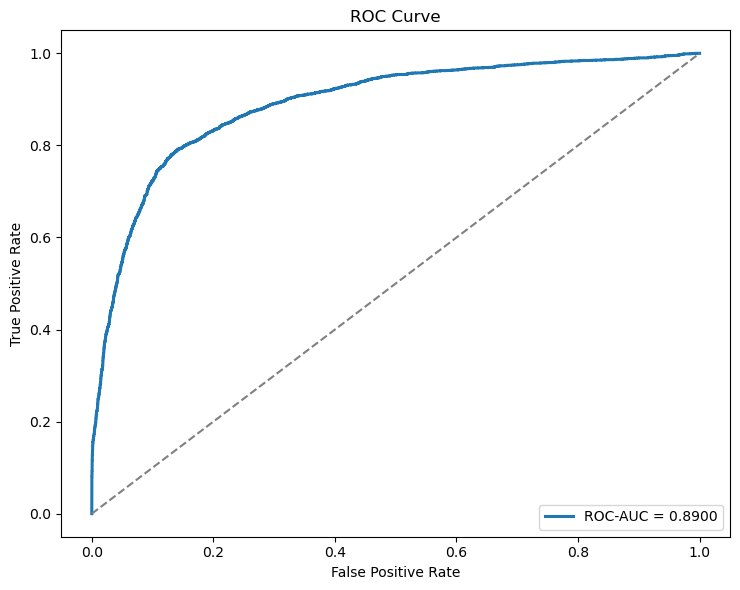

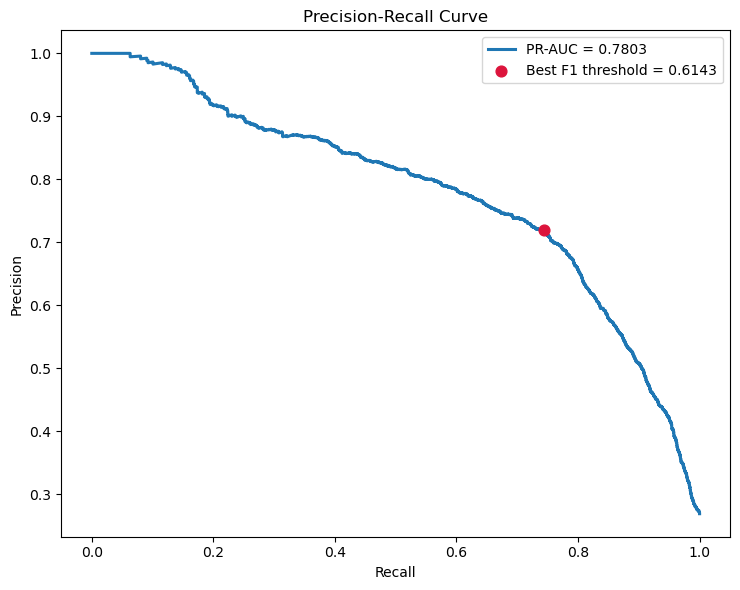

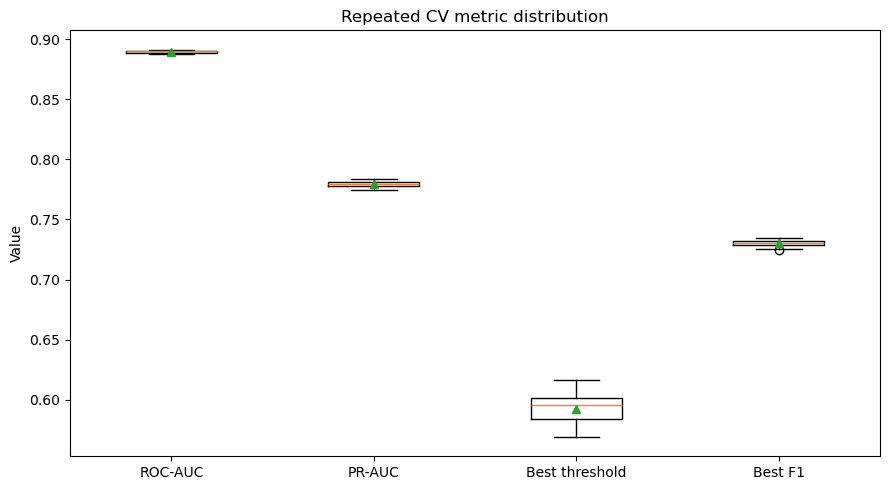

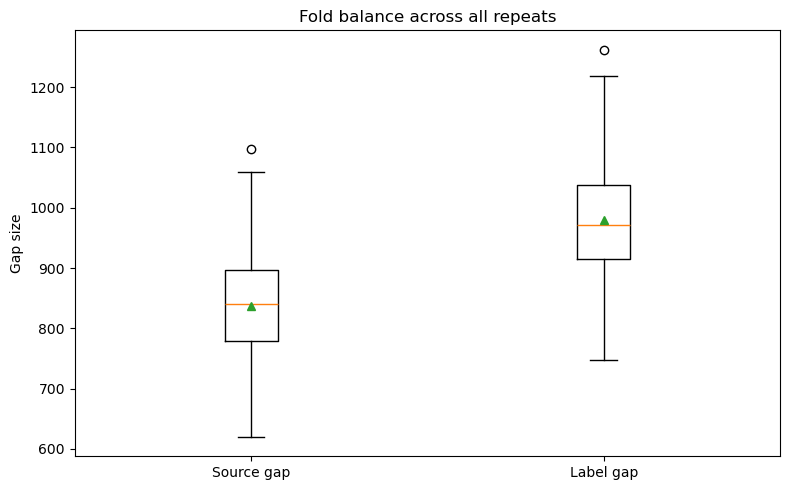


Saved files:
- /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train/repeated_cv_mean_oof_roc_curve.png
- /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train/repeated_cv_mean_oof_pr_curve.png
- /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train/repeat_metric_boxplot.png
- /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train/fold_balance_boxplot.png


In [9]:
# =====================
# 子模块4: 50 次重复 CV 的综合评估、阈值与曲线保存
# =====================
mean_oof_prob = repeat_oof_matrix.mean(axis=0)
std_oof_prob = repeat_oof_matrix.std(axis=0, ddof=1)

aggregate_eval = evaluate_probability_predictions(y_all, mean_oof_prob)

prediction_summary_df = model_df[[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN]].copy()
prediction_summary_df["mean_oof_prob"] = mean_oof_prob
prediction_summary_df["std_oof_prob"] = std_oof_prob
prediction_summary_df["mean_oof_pred"] = (
    prediction_summary_df["mean_oof_prob"] >= aggregate_eval["best_threshold"]
).astype(int)

repeat_summary_df.to_csv(OUTPUT_DIR / "repeat_cv_summary.csv", index=False)
repeat_fold_summary_df.to_csv(OUTPUT_DIR / "repeat_fold_summary.csv", index=False)
prediction_summary_df.to_csv(OUTPUT_DIR / "repeat_oof_predictions.csv", index=False)
repeat_parameter_df.to_csv(OUTPUT_DIR / "repeat_parameter_summary.csv", index=False)

aggregate_summary_df = pd.DataFrame(
    [
        {
            "roc_auc": aggregate_eval["roc_auc"],
            "pr_auc": aggregate_eval["pr_auc"],
            "best_threshold": aggregate_eval["best_threshold"],
            "best_precision": aggregate_eval["best_precision"],
            "best_recall": aggregate_eval["best_recall"],
            "best_f1": aggregate_eval["best_f1"],
            "accuracy": aggregate_eval["accuracy"],
            "balanced_accuracy": aggregate_eval["balanced_accuracy"],
            "precision": aggregate_eval["precision"],
            "recall": aggregate_eval["recall"],
            "f1": aggregate_eval["f1"],
            "tn": aggregate_eval["tn"],
            "fp": aggregate_eval["fp"],
            "fn": aggregate_eval["fn"],
            "tp": aggregate_eval["tp"],
        }
    ]
)
aggregate_summary_df.to_csv(OUTPUT_DIR / "aggregate_oof_summary.csv", index=False)

print("Repeated CV summary (mean ± std):")
print(
    repeat_summary_df[
        [
            "roc_auc",
            "pr_auc",
            "best_threshold",
            "best_f1",
            "fold_source_gap_mean",
            "fold_label_gap_mean",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

print("\nSplit quality across repeats:")
print(repeat_summary_df["split_ok"].value_counts(dropna=False))

print("\nOverall fold balance across all repeats:")
print(
    repeat_fold_summary_df[
        [
            "n_test",
            "n_pos",
            "n_neg",
            "n_af3",
            "n_rosetta",
            "label_gap",
            "source_gap",
        ]
    ]
    .agg(["mean", "std"])
    .round(2)
)

print("\nAggregated mean OOF metrics:")
print(aggregate_summary_df.T.round(6))

plot_and_save_curves(
    y_true=y_all,
    y_prob=mean_oof_prob,
    best_threshold=aggregate_eval["best_threshold"],
    output_dir=OUTPUT_DIR,
    prefix="repeated_cv_mean_oof",
)

plt.figure(figsize=(9, 5))
plt.boxplot(
    [
        repeat_summary_df["roc_auc"],
        repeat_summary_df["pr_auc"],
        repeat_summary_df["best_threshold"],
        repeat_summary_df["best_f1"],
    ],
    tick_labels=["ROC-AUC", "PR-AUC", "Best threshold", "Best F1"],
    showmeans=True,
)
plt.ylabel("Value")
plt.title("Repeated CV metric distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "repeat_metric_boxplot.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(
    [repeat_fold_summary_df["source_gap"], repeat_fold_summary_df["label_gap"]],
    tick_labels=["Source gap", "Label gap"],
    showmeans=True,
)
plt.ylabel("Gap size")
plt.title("Fold balance across all repeats")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fold_balance_boxplot.png", dpi=300)
plt.show()

print("\nSaved files:")
print(f"- {OUTPUT_DIR / 'repeated_cv_mean_oof_roc_curve.png'}")
print(f"- {OUTPUT_DIR / 'repeated_cv_mean_oof_pr_curve.png'}")
print(f"- {OUTPUT_DIR / 'repeat_metric_boxplot.png'}")
print(f"- {OUTPUT_DIR / 'fold_balance_boxplot.png'}")

In [10]:
# =====================
# 子模块5: 最终模型、参数报告与公式导出
# =====================
final_model = build_model(random_state=BASE_SEED)
full_y = model_df[LABEL_COLUMN].astype(int).to_numpy()
full_weights = compute_sample_weights(full_y)

final_model.fit(
    model_df[FEATURE_COLUMNS],
    full_y,
    clf__sample_weight=full_weights,
)

(
    final_raw_table,
    final_standardized_table,
    final_raw_coef,
    final_raw_bias,
    final_standardized_coef,
    final_standardized_bias,
) = extract_raw_parameters(final_model)

final_param_report_df = pd.DataFrame(
    {
        "term": ["bias"] + FEATURE_COLUMNS,
        "raw_coefficient": [final_raw_bias] + list(final_raw_coef),
        "standardized_coefficient": [final_standardized_bias] + list(final_standardized_coef),
    }
)

repeat_parameter_stats_df = (
    repeat_parameter_df.drop(columns=["repeat"])
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "term"})
)

formula_text = format_glm_formula(
    feature_names=FEATURE_COLUMNS,
    coefficients=final_raw_coef,
    bias=final_raw_bias,
)

threshold_text = (
    f"Best threshold from repeated CV mean OOF PR curve: {aggregate_eval['best_threshold']:.6f}\n"
    f"Best F1: {aggregate_eval['best_f1']:.6f}\n"
    f"Precision: {aggregate_eval['best_precision']:.6f}\n"
    f"Recall: {aggregate_eval['best_recall']:.6f}\n"
    f"ROC-AUC: {aggregate_eval['roc_auc']:.6f}\n"
    f"PR-AUC: {aggregate_eval['pr_auc']:.6f}"
)

report_text = "\n".join(
    [
        "Final GLM formula:",
        formula_text,
        "",
        threshold_text,
        "",
        "Final parameter table:",
        final_param_report_df.to_string(index=False),
        "",
        "Repeated CV parameter stability (mean ± std across 50 repeats):",
        repeat_parameter_stats_df.to_string(index=False),
    ]
)

final_report_path = OUTPUT_DIR / "final_glm_report.txt"
final_report_path.write_text(report_text, encoding="utf-8")
final_param_report_df.to_csv(OUTPUT_DIR / "final_glm_parameters.csv", index=False)
repeat_parameter_stats_df.to_csv(OUTPUT_DIR / "repeat_parameter_stats.csv", index=False)

print(report_text)
print(f"\nSaved final report to: {final_report_path}")
print(f"Saved parameter table to: {OUTPUT_DIR / 'final_glm_parameters.csv'}")
print(f"Saved repeat parameter stats to: {OUTPUT_DIR / 'repeat_parameter_stats.csv'}")

Final GLM formula:
logit = (-7.642893) + (-1.883335) * dG_separated/dSASAx100 + (-0.259190) * energy_per_intres + (0.027662) * dSASA_int_per_res
probability = 1 / (1 + exp(-logit))

Best threshold from repeated CV mean OOF PR curve: 0.614306
Best F1: 0.731438
Precision: 0.718930
Recall: 0.744390
ROC-AUC: 0.890039
PR-AUC: 0.780330

Final parameter table:
                  term  raw_coefficient  standardized_coefficient
                  bias        -7.642893                 -0.678827
dG_separated/dSASAx100        -1.883335                 -1.790838
     energy_per_intres        -0.259190                 -0.321273
     dSASA_int_per_res         0.027662                  1.034709

Repeated CV parameter stability (mean ± std across 50 repeats):
                                term      mean      std
                       raw_bias_mean -7.696139 0.014244
                       std_bias_mean -0.682265 0.001482
raw_coef_mean_dG_separated_dSASAx100 -1.871166 0.003846
     raw_coef_mean_energy